# Mean-Variance Optimization (MVO) Portfolio

Based on the two Top-6 selection CSVs produced by OLS and Random Forest models.

**Logic:**
- Each month T: use the 6 selected stocks + their predicted returns as μ
- Estimate Σ from all available historical MthRet up to month T (rolling)
- Solve max-Sharpe MVO with long-only + weight cap constraints
- Realized portfolio return = w* · y_next (next-month excess returns)
- Compare OLS+MVO vs RF+MVO vs Equal-Weight benchmark

In [9]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.6f}".format)

## 1. Load Data

In [10]:
top6_ols = pd.read_csv("../data/ols_top6_by_month_post2022.csv")
top6_rf = pd.read_csv("../data/rf_top6_by_month_post2022.csv")

top6_ols["MthCalDt"] = pd.to_datetime(top6_ols["MthCalDt"])
top6_rf["MthCalDt"] = pd.to_datetime(top6_rf["MthCalDt"])

print(
    "OLS shape:",
    top6_ols.shape,
    "| months:",
    top6_ols["DateKey"].nunique(),
    "| unique stocks:",
    top6_ols["PERMNO"].nunique(),
)
print(
    "RF  shape:",
    top6_rf.shape,
    "| months:",
    top6_rf["DateKey"].nunique(),
    "| unique stocks:",
    top6_rf["PERMNO"].nunique(),
)
display(top6_ols.head(3))

OLS shape: (282, 26) | months: 47 | unique stocks: 230
RF  shape: (282, 26) | months: 47 | unique stocks: 99


,PERMNO,HdrCUSIP,Ticker,PERMCO,MthCalDt,MthPrc,MthCap,MthRet,ShrOut,MthPrc_Abs,...,RF,ExcessRet,y_next,ret_lag1,ret_lag2,ret_lag3,history_len,log_size,predicted_return,rank
0,12759,75989230,RENN,53760,2022-01-31,21.890000,113083.740000,0.491144,5166,21.890000,...,0.000000,0.442129,0.037003,-0.302113,0.037510,0.442129,36,11.635884,0.030169,3.000000
1,13323,29355A10,ENPH,54026,2022-01-31,140.470000,18808090.180000,-0.232153,133894,140.470000,...,0.000000,-0.232153,0.186730,-0.268340,0.079308,0.442129,70,16.749798,0.029455,6.000000
2,18184,33813J10,FSR,56480,2022-01-31,11.810000,1941162.460000,-0.249205,164366,11.810000,...,0.000000,-0.249205,0.033023,-0.264710,0.332710,0.095563,36,14.478798,0.029513,5.000000


In [11]:
top6_rf.groupby("Ticker")["predicted_return"].describe()

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AADR,14.000000,-0.012329,0.010103,-0.030575,-0.018268,-0.013602,-0.005699,0.011147
ADM,1.000000,0.050807,NaN,0.050807,0.050807,0.050807,0.050807,0.050807
ADX,29.000000,0.000813,0.015337,-0.021497,-0.011699,-0.005164,0.015874,0.027620
AIRT,1.000000,-0.019938,NaN,-0.019938,-0.019938,-0.019938,-0.019938,-0.019938
ALCO,1.000000,-0.019938,NaN,-0.019938,-0.019938,-0.019938,-0.019938,-0.019938
...,...,...,...,...,...,...,...,...
VKTX,1.000000,0.148033,NaN,0.148033,0.148033,0.148033,0.148033,0.148033
WB,1.000000,0.133198,NaN,0.133198,0.133198,0.133198,0.133198,0.133198
XOMA,1.000000,0.036432,NaN,0.036432,0.036432,0.036432,0.036432,0.036432


## 2. MVO Core Function

In [12]:
def max_sharpe_weights(mu, cov, weight_cap=0.40):
    """
    Solve the maximum Sharpe Ratio portfolio:

        max   w'μ / sqrt(w'Σw)
        s.t.  sum(w) = 1
              0 <= w_i <= weight_cap

    Falls back to equal-weight if the optimizer does not converge.
    A small diagonal regularization (1e-6) is added to Σ to handle
    near-singular matrices.
    """
    n = len(mu)
    w0 = np.ones(n) / n
    cov_reg = cov + np.eye(n) * 1e-6

    def neg_sharpe(w):
        ret = w @ mu
        vol = np.sqrt(max(w @ cov_reg @ w, 1e-12))
        return -ret / vol

    result = minimize(
        neg_sharpe,
        w0,
        method="SLSQP",
        bounds=[(0.0, weight_cap)] * n,
        constraints=[{"type": "eq", "fun": lambda w: np.sum(w) - 1}],
        options={"ftol": 1e-9, "maxiter": 1000},
    )

    if result.success:
        w = np.clip(result.x, 0, weight_cap)
        return w / w.sum()
    return w0

## 3. OLS + MVO  —  Diagonal Covariance + Rank-Transformed μ

**Why diagonal covariance?**  
The OLS model selects from a pool of ~230 different stocks over 47 months. Any two stocks chosen in a given month rarely share more than 1–2 months of overlapping return history in the dataset, making a full covariance matrix unreliable. Using a diagonal matrix (each stock's own historical variance, with zero off-diagonal correlations) is the standard fallback in this setting.

**Why rank-transform μ?**  
The OLS predicted returns have very small cross-sectional spread (often < 0.005 in a given month). When fed directly into the Sharpe optimizer alongside individual stock variances of ~3–5%, the tiny return differences are dominated by noise, and the optimizer effectively returns equal weights. Converting ranks to a [0, 0.10] scale creates a stable, meaningful signal for the optimizer to act on.

In [13]:
def run_ols_mvo(top6_df, weight_cap=0.25, cov_window=36):
    """
    OLS portfolio construction:
    - Covariance: diagonal matrix of each stock's rolling historical variance
    - mu: rank-transformed predicted returns scaled to [0, 0.10]
    - weight_cap: 0.25 (tighter than 0.40 to improve diversification)
    """
    all_months = sorted(top6_df["DateKey"].unique())
    records = []

    for i, month in enumerate(all_months):
        md = top6_df[top6_df["DateKey"] == month].copy()
        permnos = md["PERMNO"].tolist()
        mu_raw = md["predicted_return"].values
        y = md["y_next"].values
        tickers = md["Ticker"].tolist()

        # ── Rank-transform predicted returns ──────────────────────────────────
        # Converts the tiny raw spread into a [0, 0.10] signal the optimizer
        # can meaningfully act on.
        ranks = mu_raw.argsort().argsort().astype(float)  # 0, 1, ..., 5
        mu_scaled = (ranks / max(ranks.max(), 1)) * 0.10

        # ── Diagonal covariance: each stock's own rolling variance ─────────────
        start = max(0, i - cov_window)
        hist_months = all_months[start:i]
        variances = []
        for p in permnos:
            hist_ret = top6_df[
                (top6_df["PERMNO"] == p) & (top6_df["DateKey"].isin(hist_months))
            ]["MthRet"]
            # Fallback variance = (20% annual vol / sqrt(12))^2 if history < 2 obs
            variances.append(
                hist_ret.var() if len(hist_ret) >= 2 else (0.20 / np.sqrt(12)) ** 2
            )
        cov = np.diag(variances)

        # ── Solve MVO ─────────────────────────────────────────────────────────
        if i == 0:
            w = np.ones(len(permnos)) / len(permnos)  # first month: equal-weight
        else:
            w = max_sharpe_weights(mu_scaled, cov, weight_cap=weight_cap)

        w_ew = np.ones(len(permnos)) / len(permnos)

        records.append(
            {
                "DateKey": month,
                "tickers": tickers,
                "mu_raw": mu_raw.tolist(),
                "mu_scaled": mu_scaled.tolist(),
                "weights_opt": w.tolist(),
                "ret_opt": float(w @ y),
                "ret_ew": float(w_ew @ y),
            }
        )

    result_df = pd.DataFrame(records)
    print(f"[OLS+MVO] Done. {len(result_df)} months | weight_cap={weight_cap}")
    return result_df


results_ols = run_ols_mvo(top6_ols, weight_cap=0.25)

[OLS+MVO] Done. 47 months | weight_cap=0.25


## 4. RF + MVO  —  Ledoit-Wolf Shrinkage Covariance

**Why Ledoit-Wolf?**  
The RF model draws from only 9 stocks, giving a stable return history across all 47 months. However, with at most 36 observations and 6 assets, the sample covariance matrix can still be noisy. Ledoit-Wolf shrinkage pulls the sample covariance toward a scaled identity matrix, reducing estimation error — a well-established technique in empirical portfolio optimization (Ledoit & Wolf, 2004).

**μ**: raw predicted returns (not rank-transformed), because the RF produces a wider and more meaningful cross-sectional spread than OLS.

In [20]:
def run_rf_mvo(top6_df, weight_cap=0.25, cov_window=36, min_hist=3):
    """
    RF portfolio construction:
    - Covariance: Ledoit-Wolf shrinkage on rolling 36-month return panel
      Missing values filled with column mean before fitting.
    - mu: raw predicted returns from the RF model
    - weight_cap: 0.25 for consistency with OLS comparison
    - min_hist: minimum months of history required before running MVO
    """

    all_months = sorted(top6_df["DateKey"].unique())
    records = []

    for i, month in enumerate(all_months):

        md = top6_df[top6_df["DateKey"] == month].copy()

        permnos = md["PERMNO"].tolist()
        mu = md["predicted_return"].values
        y = md["y_next"].values
        tickers = md["Ticker"].tolist()

        # ── Build rolling return history panel ────────────────────────────────
        start = max(0, i - cov_window)
        hist_months = all_months[start:i]

        hist = top6_df[top6_df["DateKey"].isin(hist_months)].pivot_table(
            index="DateKey", columns="PERMNO", values="MthRet"
        )

        hist = hist[[p for p in permnos if p in hist.columns]]

        # Fill missing values with column mean
        hist = hist.fillna(hist.mean())

        # ── Ledoit-Wolf covariance or equal-weight fallback ───────────────────
        if i < min_hist or hist.shape[0] < min_hist:

            w = np.ones(len(permnos)) / len(permnos)

        else:

            try:
                cov = LedoitWolf().fit(hist.values).covariance_

                w = max_sharpe_weights(mu, cov, weight_cap=weight_cap)

            except Exception:
                w = np.ones(len(permnos)) / len(permnos)

        w_ew = np.ones(len(permnos)) / len(permnos)

        records.append(
            {
                "DateKey": month,
                "tickers": tickers,
                "mu": mu.tolist(),
                "weights_opt": w.tolist(),
                "ret_opt": float(w @ y),
                "ret_ew": float(w_ew @ y),
            }
        )

    result_df = pd.DataFrame(records)

    print(
        f"[RF+MVO] Done. {len(result_df)} months | "
        f"weight_cap={weight_cap} | min_hist={min_hist}"
    )

    return result_df


results_rf = run_rf_mvo(top6_rf, weight_cap=0.25, min_hist=3)

[RF+MVO] Done. 47 months | weight_cap=0.25 | min_hist=3


## 5. Performance Metrics

In [15]:
def performance_metrics(ret_series, label=""):
    """Methodology §12.2 metrics from monthly excess return series."""
    r = np.array(ret_series)
    T = len(r)

    ann_ret = (1 + r).prod() ** (12 / T) - 1  # §12.2.1
    ann_vol = r.std() * np.sqrt(12)  # §12.2.2
    sharpe = (r.mean() / r.std()) * np.sqrt(12)  # §12.2.3 (r already excess)

    wealth = (1 + r).cumprod()  # §12.2.4
    peak = np.maximum.accumulate(wealth)
    mdd = ((peak - wealth) / peak).max()

    return {
        "Portfolio": label,
        "Ann. Return": ann_ret,
        "Ann. Vol": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": mdd,
    }


metrics = [
    performance_metrics(results_ols["ret_opt"], "OLS + MVO"),
    performance_metrics(results_rf["ret_opt"], "RF  + MVO"),
    performance_metrics(results_ols["ret_ew"], "Equal-Weight (OLS stocks)"),
    performance_metrics(results_rf["ret_ew"], "Equal-Weight (RF stocks)"),
]

perf_table = pd.DataFrame(metrics).set_index("Portfolio")
perf_table_fmt = perf_table.copy()
for col in perf_table_fmt.columns:
    perf_table_fmt[col] = perf_table_fmt[col].map("{:.4f}".format)

print("\n=== PORTFOLIO PERFORMANCE TABLE (Methodology §13.2) ===")
display(perf_table_fmt)


=== PORTFOLIO PERFORMANCE TABLE (Methodology §13.2) ===


,Ann. Return,Ann. Vol,Sharpe Ratio,Max Drawdown
Portfolio,,,,
OLS + MVO,0.0582,0.3401,0.3388,0.4012
RF + MVO,0.2247,0.1950,1.1468,0.2024
Equal-Weight (OLS stocks),0.0273,0.3110,0.2464,0.3147
Equal-Weight (RF stocks),0.2242,0.1807,1.2200,0.1828


## 6. Monthly Weight Inspection

In [16]:
def show_weights(results_df, label, n_months=2):
    rows = []
    for _, row in results_df.iterrows():
        if "mu_scaled" in results_df.columns:
            mu_vals = row["mu_scaled"]
        else:
            mu_vals = row["mu"]

        for ticker, w, mu in zip(row["tickers"], row["weights_opt"], mu_vals):
            rows.append(
                {
                    "DateKey": row["DateKey"],
                    "Ticker": ticker,
                    "Pred Signal": mu,
                    "Weight": w,
                }
            )

    df = pd.DataFrame(rows)
    sample_months = sorted(df["DateKey"].unique())[:n_months]
    print(f"\n[{label}] Weights — first {n_months} months:")
    display(
        df[df["DateKey"].isin(sample_months)]
        .sort_values(["DateKey", "Weight"], ascending=[True, False])
        .reset_index(drop=True)
    )


show_weights(results_ols, "OLS+MVO")
show_weights(results_rf, "RF+MVO")


[OLS+MVO] Weights — first 2 months:


,DateKey,Ticker,Pred Signal,Weight
0,202201,RENN,0.060000,0.166667
1,202201,ENPH,0.000000,0.166667
2,202201,FSR,0.020000,0.166667
3,202201,CAR,0.100000,0.166667
4,202201,PLUG,0.040000,0.166667
5,202201,RIOT,0.080000,0.166667
6,202202,TRT,0.100000,0.250000
7,202202,BXC,0.080000,0.250000
8,202202,ACET,0.060000,0.218754
9,202202,KOLD,0.040000,0.156258



[RF+MVO] Weights — first 2 months:


,DateKey,Ticker,Pred Signal,Weight
0,202201,INDB,0.050807,0.166667
1,202201,AMWD,0.050807,0.166667
2,202201,ADM,0.050807,0.166667
3,202201,CERN,0.050807,0.166667
4,202201,MKL,0.050807,0.166667
5,202201,FBNC,0.050807,0.166667
6,202202,DLHC,0.086181,0.166667
7,202202,CLFD,0.086181,0.166667
8,202202,CERN,0.086181,0.166667
9,202202,PLAB,0.086181,0.166667


## 7. Cumulative Wealth Curves

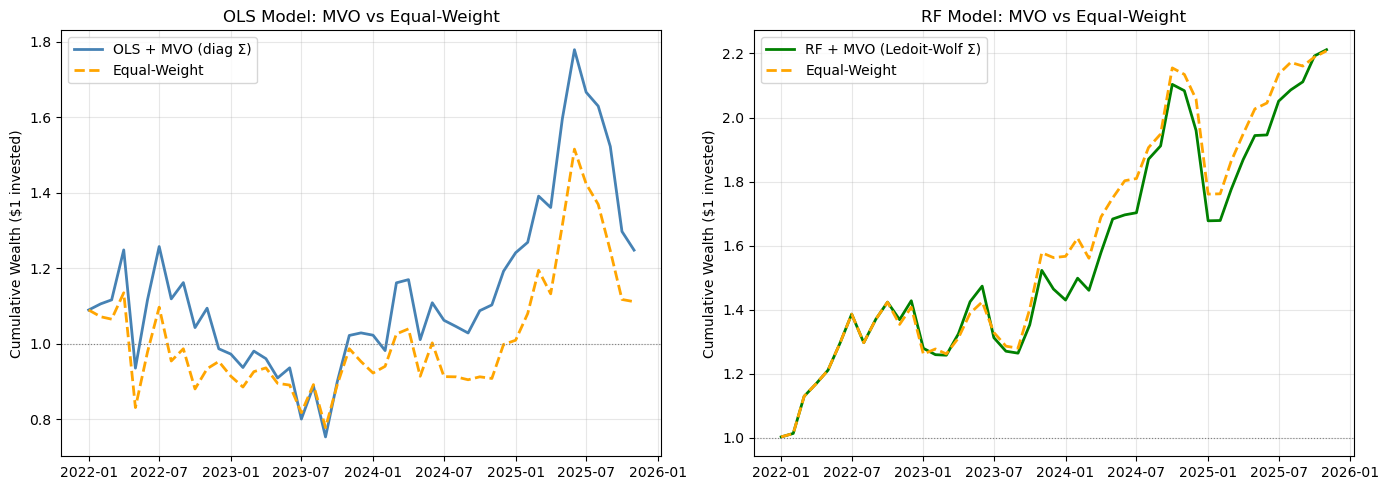

Saved: wealth_curves_v2.png


In [17]:
months = pd.to_datetime(results_ols["DateKey"].astype(str), format="%Y%m")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── OLS panel ────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(
    months,
    (1 + results_ols["ret_opt"]).cumprod(),
    label="OLS + MVO (diag Σ)",
    linewidth=2,
    color="steelblue",
)
ax.plot(
    months,
    (1 + results_ols["ret_ew"]).cumprod(),
    label="Equal-Weight",
    linewidth=2,
    linestyle="--",
    color="orange",
)
ax.axhline(1, color="grey", linewidth=0.8, linestyle=":")
ax.set_title("OLS Model: MVO vs Equal-Weight")
ax.set_ylabel("Cumulative Wealth ($1 invested)")
ax.legend()
ax.grid(True, alpha=0.3)

# ── RF panel ─────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(
    months,
    (1 + results_rf["ret_opt"]).cumprod(),
    label="RF + MVO (Ledoit-Wolf Σ)",
    linewidth=2,
    color="green",
)
ax.plot(
    months,
    (1 + results_rf["ret_ew"]).cumprod(),
    label="Equal-Weight",
    linewidth=2,
    linestyle="--",
    color="orange",
)
ax.axhline(1, color="grey", linewidth=0.8, linestyle=":")
ax.set_title("RF Model: MVO vs Equal-Weight")
ax.set_ylabel("Cumulative Wealth ($1 invested)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("wealth_curves_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: wealth_curves_v2.png")

## 8. OLS vs RF Head-to-Head

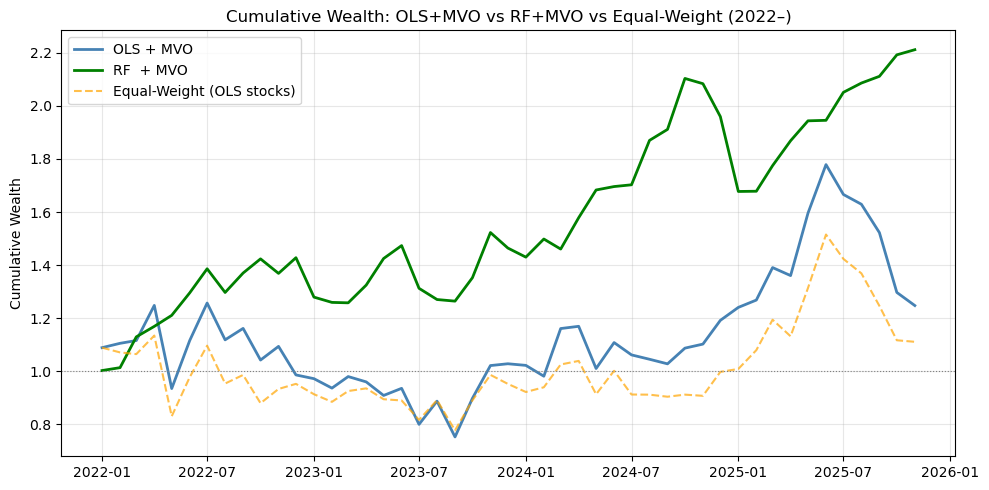

Saved: head_to_head_v2.png


In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    months,
    (1 + results_ols["ret_opt"]).cumprod(),
    label="OLS + MVO",
    linewidth=2,
    color="steelblue",
)
ax.plot(
    months,
    (1 + results_rf["ret_opt"]).cumprod(),
    label="RF  + MVO",
    linewidth=2,
    color="green",
)
ax.plot(
    months,
    (1 + results_ols["ret_ew"]).cumprod(),
    label="Equal-Weight (OLS stocks)",
    linewidth=1.5,
    linestyle="--",
    alpha=0.7,
    color="orange",
)
ax.axhline(1, color="grey", linewidth=0.8, linestyle=":")
ax.set_title("Cumulative Wealth: OLS+MVO vs RF+MVO vs Equal-Weight (2022–)")
ax.set_ylabel("Cumulative Wealth")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("head_to_head_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: head_to_head_v2.png")

## 9. Save Results

In [19]:
monthly_ret = pd.DataFrame(
    {
        "DateKey": results_ols["DateKey"].values,
        "OLS_MVO": results_ols["ret_opt"].values,
        "RF_MVO": results_rf["ret_opt"].values,
        "EW_OLS_stocks": results_ols["ret_ew"].values,
        "EW_RF_stocks": results_rf["ret_ew"].values,
    }
)

monthly_ret.to_csv(
    r"C:\Users\24458\Desktop\586\MVO data\mvo_monthly_returns_v2.csv", index=False
)
perf_table.to_csv(
    r"C:\Users\24458\Desktop\586\MVO data\mvo_performance_summary_v2.csv", index=False
)

print("Saved: mvo_monthly_returns_v2.csv")
print("Saved: mvo_performance_summary_v2.csv")
display(monthly_ret)

Saved: mvo_monthly_returns_v2.csv
Saved: mvo_performance_summary_v2.csv


,DateKey,OLS_MVO,RF_MVO,EW_OLS_stocks,EW_RF_stocks
0,202201,0.089212,0.003008,0.089212,0.003008
1,202202,0.014990,0.010832,-0.016442,0.010832
2,202203,0.009496,0.114414,-0.006003,0.114414
3,202204,0.118569,0.034969,0.065627,0.034969
4,202205,-0.250877,0.035546,-0.267956,0.035546
5,202206,0.193346,0.069964,0.177066,0.069964
6,202207,0.126625,0.069980,0.121596,0.069980
7,202208,-0.110264,-0.064339,-0.130077,-0.064339
8,202209,0.038554,0.056489,0.033995,0.056489
9,202210,-0.102629,0.038889,-0.107930,0.038889
